# SFT Model Qwen3-0.6B với LoRA

## Mục tiêu
Fine-tune model Qwen/Qwen2.5-0.5B trên dataset openai/gsm8k

## Công nghệ sử dụng
- **Model**: Qwen/Qwen2.5-0.5B (SLM)
- **Phương pháp**: LoRA
- **Dataset**: openai/gsm8k (Hunggingface): https://huggingface.co/datasets/openai/gsm8k
- **Framework**: Transformers, PEFT, TRL

## Qwen/Qwen2.5-0.5B has the following features:

- Type: Causal Language Models
- Training Stage: Pretraining
- Architecture: transformers with RoPE, SwiGLU, RMSNorm, Attention QKV bias and tied word embeddings
- Number of Parameters: 0.49B
- Number of Paramaters (Non-Embedding): 0.36B
- Number of Layers: 24
- Number of Attention Heads (GQA): 14 for Q and 2 for KV
- Context Length: Full 32,768 tokens

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cài đặt các thư viện cần thiết
!pip install -qU transformers datasets peft trl accelerate bitsandbytes wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 12.5 MB/s eta 0:00:00


## Giải thích các thư viện

- **transformers**: Load model và tokenizer từ HuggingFace
- **datasets**: Load và xử lý dataset
- **peft**: Parameter-Efficient Fine-Tuning (LoRA)
- **trl**: Transformer Reinforcement Learning (SFTTrainer)
- **accelerate**: Tăng tốc training
- **bitsandbytes**: Quantization (4-bit, 8-bit)
- **wandb**: Tracking experiments (optional)

## Check Cuda

In [3]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from datasets import load_dataset
from trl import SFTTrainer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: Tesla T4


## Bước 1: Load Dataset

Dataset **openai/gsm8k**: GSM8K (Grade School Math 8K) là bộ dữ liệu gồm 8,5K bài toán đố chất lượng cao dành cho học sinh cấp lớp đa dạng về mặt ngôn ngữ. Bộ dữ liệu được tạo ra để hỗ trợ nhiệm vụ trả lời câu hỏi về các vấn đề toán học cơ bản đòi hỏi phải suy luận nhiều bước.
- Những vấn đề này cần từ 2 đến 8 bước để giải quyết.
- Các giải pháp chủ yếu liên quan đến việc thực hiện một chuỗi các phép tính cơ bản bằng cách sử dụng các phép tính số học cơ bản (+ - × `) để đi đến câu trả lời cuối cùng.
- Một học sinh trung học thông minh sẽ có thể giải quyết mọi vấn đề: theo bài báo, "Các vấn đề không yêu cầu khái niệm nào vượt quá trình độ Đại số sơ cấp và phần lớn các vấn đề có thể được giải quyết mà không cần xác định rõ ràng một biến."
- Các giải pháp được cung cấp bằng ngôn ngữ tự nhiên, trái ngược với các biểu thức toán học thuần túy. Từ bài báo: "Chúng tôi tin rằng đây là định dạng dữ liệu hữu ích nhất và chúng tôi hy vọng nó sẽ làm sáng tỏ các đặc tính của độc thoại nội tâm của các mô hình ngôn ngữ lớn""

**Cấu trúc dữ liệu**:
- `question`: Câu hỏi
- `answer`: Đáp án

In [4]:
# Load dataset
dataset = load_dataset("openai/gsm8k", "main")

print("Dataset structure:")
print(dataset)

# Xem mẫu dữ liệu
print("\nSample data:")
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['question', 'answer'],
        num_rows: 7473
    })
    test: Dataset({
        features: ['question', 'answer'],
        num_rows: 1319
    })
})

Sample data:
{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72'}


## Bước 2: Chuẩn bị dữ liệu

**Format prompt**: Tạo template instruction cho model

```
### Instruction:
Hãy giải quyết bài toán sau :

### question:
{question}

### answer:
{answer}
```

**Lý do**: Format này giúp model hiểu rõ task và context

In [5]:
def format_instruction(sample):
    """Format dữ liệu thành instruction template"""
    return f"""### Instruction:
    Hãy giải quyết bài toán sau :

    ### question:
    {sample['question']}

    ### answer:
    {sample['answer']}

"""

# Test format
print(format_instruction(dataset['train'][0]))

### Instruction:
    Hãy giải quyết bài toán sau :

    ### question:
    Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

    ### answer:
    Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
#### 72




## Bước 3: Load Model với Quantization

**4-bit Quantization**:
- Giảm memory từ 16-bit → 4-bit
- Model 0.6B: ~1.2GB → ~0.3GB
- **compute_dtype**: float16 cho tính toán
- **quant_type**: nf4 (NormalFloat4) - tối ưu cho neural networks

In [6]:
## Chưa Quant_type


# Load model
model_name = "Qwen/Qwen2.5-0.5B"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    trust_remote_code=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Model loaded: {model_name}")
print(f"Model size: {model.get_memory_footprint() / 1e9:.2f} GB")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded: Qwen/Qwen2.5-0.5B
Model size: 1.98 GB


In [7]:

# QLoRA Config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load model
model_name = "Qwen/Qwen2.5-0.5B"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    trust_remote_code=True,
    quantization_config=bnb_config,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Model loaded: {model_name}")
print(f"Model size: {model.get_memory_footprint() / 1e9:.2f} GB")

Model loaded: Qwen/Qwen2.5-0.5B
Model size: 0.45 GB


## Bước 4: Cấu hình LoRA

**LoRA Parameters**:
- **r=16**: Rank của low-rank matrices (càng cao càng flexible nhưng tốn memory)
- **lora_alpha=32**: Scaling factor (thường = 2*r)
- **lora_dropout=0.05**: Regularization
- **target_modules**: Layers áp dụng LoRA (q_proj, v_proj cho attention)
- **bias="none"**: Không train bias
- **task_type="CAUSAL_LM"**: Language modeling task

In [8]:
# Cấu hình LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Chuẩn bị model cho k-bit training
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, lora_config)

# In số lượng parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")
print(f"All params: {all_params:,}")

Trainable params: 2,162,688 (0.68%)
All params: 317,282,176


## Bước 5: Training Arguments

**Hyperparameters quan trọng**:
- **num_train_epochs**: Số epoch (3 là phù hợp cho SFT)
- **per_device_train_batch_size**: Batch size (4-8 tùy GPU)
- **gradient_accumulation_steps**: Tích lũy gradient (tăng effective batch size)
- **learning_rate**: 2e-4 là standard cho LoRA
- **fp16/bf16**: Mixed precision training
- **max_grad_norm**: Gradient clipping (tránh exploding gradients)

In [9]:
training_args = TrainingArguments(
    output_dir=".Qwen/Qwen2.5-0.5B/SFT",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    fp16=True,
    save_total_limit=2,
    logging_steps=10,
    save_steps=100,
    warmup_steps=50,
    max_grad_norm=0.3,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
)

print("Training configuration:")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")

Training configuration:
Effective batch size: 4


## Bước 6: Khởi tạo SFTTrainer

**SFTTrainer** (Supervised Fine-Tuning Trainer):
- Tự động xử lý formatting
- Tối ưu cho instruction tuning


In [10]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset['train'],
    args=training_args,
    formatting_func=format_instruction,
)

print("Trainer initialized successfully!")

Applying formatting function to train dataset:   0%|          | 0/7473 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/7473 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7473 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7473 [00:00<?, ? examples/s]

Trainer initialized successfully!


## Bước 7: Bắt đầu Training

**Quá trình training**:
1. Forward pass: Tính loss
2. Backward pass: Tính gradients
3. Optimizer step: Cập nhật weights (chỉ LoRA adapters)
4. Logging: Ghi lại metrics

**Thời gian ước tính**: 1-3 giờ tùy GPU và dataset size

In [ ]:
# Bắt đầu training
trainer.train()

print("Training completed!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nd-wuang26 (nd-wuang26-thai-nguyen-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,1.486500
20,1.335800
30,1.075600
40,0.855200
50,0.790600
60,0.722400
70,0.675800
80,0.596800
90,0.591100
100,0.560000


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training completed!


## Bước 8: Lưu Model

**Lưu 2 phần**:
1. **LoRA adapters**: Chỉ ~10-50MB (các weights được train)
2. **Tokenizer**: Để inference sau này

**Không cần lưu** base model (vì đã có trên HuggingFace)

In [ ]:
import os

# Định nghĩa đường dẫn lưu model
save_dir = "/content/drive/MyDrive/SFT_Models/Qwen2.5-0.5B-SFT-gsm8k"

# Tạo thư mục nếu chưa tồn tại
os.makedirs(save_dir, exist_ok=True)

# Lưu LoRA adapters
print(f"Saving LoRA adapters to {save_dir}...")
model.save_pretrained(save_dir)

# Lưu tokenizer
print(f"Saving tokenizer to {save_dir}...")
tokenizer.save_pretrained(save_dir)

# Kiểm tra các file đã được lưu
print("\nSaved files:")
for file in os.listdir(save_dir):
    file_path = os.path.join(save_dir, file)
    size = os.path.getsize(file_path) / (1024 * 1024)  # MB
    print(f"  - {file}: {size:.2f} MB")

print(f"\n✅ Model saved successfully to: {save_dir}")

Saving LoRA adapters to /content/drive/MyDrive/SFT_Models/Qwen2.5-0.5B-SFT-gsm8k...
Saving tokenizer to /content/drive/MyDrive/SFT_Models/Qwen2.5-0.5B-SFT-gsm8k...

Saved files:
  - README.md: 0.00 MB
  - adapter_model.safetensors: 8.27 MB
  - adapter_config.json: 0.00 MB
  - chat_template.jinja: 0.00 MB
  - tokenizer_config.json: 0.00 MB
  - special_tokens_map.json: 0.00 MB
  - added_tokens.json: 0.00 MB
  - vocab.json: 2.65 MB
  - merges.txt: 1.59 MB
  - tokenizer.json: 10.89 MB

✅ Model saved successfully to: /content/drive/MyDrive/SFT_Models/Qwen2.5-0.5B-SFT-gsm8k


## Bước 9: Test Model (Inference)

**Load model để test**:
1. Load base model
2. Load LoRA adapters
3. Generate text

In [11]:
from peft import PeftModel
import os

# Đường dẫn tuyệt đối đến model đã save
model_dir = "/content/drive/MyDrive/Colab Notebooks/SFT_Models/Qwen2.5-0.5B-SFT-gsm8k"

# Kiểm tra xem thư mục có tồn tại không
if not os.path.exists(model_dir):
    raise ValueError(f"Model directory not found: {model_dir}")

# Kiểm tra file adapter_config.json
adapter_config = os.path.join(model_dir, "adapter_config.json")
if not os.path.exists(adapter_config):
    raise ValueError(f"adapter_config.json not found in {model_dir}")

print(f"Loading model from: {model_dir}")

# Load base model
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,  # Để tiết kiệm memory
)

# Load LoRA adapters
print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, model_dir)

# Load tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)

print("✅ Model loaded successfully!")

# Test inference
test_text = """Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May.
 How many clips did Natalia sell altogether in April and May?"""

prompt = f"""### Instruction:
Hãy giải quyết bài toán sau:

### Question:
{test_text}

### Answer:
"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=200, temperature=0.7, do_sample=True)
result = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\n" + "="*50)
print("INFERENCE RESULT:")
print("="*50)
print(result)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model from: /content/drive/MyDrive/Colab Notebooks/SFT_Models/Qwen2.5-0.5B-SFT-gsm8k
Loading base model...
Loading LoRA adapters...
Loading tokenizer...


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


✅ Model loaded successfully!

INFERENCE RESULT:
### Instruction:
Hãy giải quyết bài toán sau:

### Question:
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May.
 How many clips did Natalia sell altogether in April and May?

### Answer:
In May, Natalia sold 48 / 2 = <<48/2=24>>24 clips.
Altogether, Natalia sold 48 + 24 = <<48+24=72>>72 clips in April and May.
#### 72




## Bước 10: Đánh giá Model trên Test Set

**Mục tiêu**: Đánh giá hiệu suất của model trên bộ test GSM8K

**Metrics sử dụng**:
1. **Exact Match Accuracy**: Tỷ lệ câu trả lời chính xác hoàn toàn
2. **BLEU Score**: Đánh giá chất lượng văn bản sinh ra
3. **ROUGE Scores**: Đánh giá độ tương đồng với câu trả lời chuẩn
4. **Perplexity**: Đo độ "bối rối" của model

**Dataset**: GSM8K test set (1,319 samples)

In [12]:
# Cài đặt thư viện đánh giá
!pip install -qU rouge-score sacrebleu

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.1 MB/s eta 0:00:00


In [13]:
import re
import numpy as np
from tqdm import tqdm
from rouge_score import rouge_scorer
from sacrebleu.metrics import BLEU
import torch.nn.functional as F

print("Evaluation libraries imported successfully!")

Evaluation libraries imported successfully!


### Hàm trích xuất đáp án từ output

GSM8K có format đặc biệt với đáp án cuối cùng sau `####`

In [14]:
def extract_answer(text):
    """
    Trích xuất đáp án số từ text.
    GSM8K format: #### [answer]
    """
    # Tìm pattern #### followed by number
    match = re.search(r'####\s*([\d,\.]+)', text)
    if match:
        # Remove commas and convert to float
        answer = match.group(1).replace(',', '')
        try:
            return float(answer)
        except:
            return None

    # Fallback: tìm số cuối cùng trong text
    numbers = re.findall(r'[\d,\.]+', text)
    if numbers:
        try:
            return float(numbers[-1].replace(',', ''))
        except:
            return None

    return None

# Test function
test_text = "Natalia sold 48+24 = <<48+24=72>>72 clips altogether.\n#### 72"
print(f"Test extraction: {extract_answer(test_text)}")

Test extraction: 72.0


### Hàm sinh câu trả lời cho test set

In [15]:
def generate_answer(question, model, tokenizer, max_new_tokens=150):
    """
    Sinh câu trả lời cho một câu hỏi
    """
    prompt = f"""### Instruction:
Hãy trả lời câu hỏi sau:

### Input:
{question}

### Response:
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # Greedy decoding for consistency
            pad_token_id=tokenizer.eos_token_id
        )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only the response part
    if "### Response:" in result:
        result = result.split("### Response:")[-1].strip()

    return result

print("Generate function defined!")

Generate function defined!


### Đánh giá trên subset của test set

**Lưu ý**: Đánh giá toàn bộ 1,319 samples có thể mất nhiều thời gian.
Ta sẽ đánh giá trên 100 samples đầu tiên để có kết quả nhanh.

In [16]:
# Số lượng samples để đánh giá (có thể thay đổi)
NUM_EVAL_SAMPLES = 100

# Lấy test set
test_dataset = dataset['test'].select(range(NUM_EVAL_SAMPLES))

print(f"Evaluating on {NUM_EVAL_SAMPLES} samples from test set...")
print(f"Total test samples: {len(dataset['test'])}")

# Lists to store results
predictions = []
references = []
exact_matches = []

# Generate predictions
for i, sample in enumerate(tqdm(test_dataset, desc="Generating predictions")):
    question = sample['question']
    reference_answer = sample['answer']

    # Generate prediction
    pred_text = generate_answer(question, model, tokenizer)

    # Extract numerical answers
    pred_num = extract_answer(pred_text)
    ref_num = extract_answer(reference_answer)

    # Store results
    predictions.append(pred_text)
    references.append(reference_answer)

    # Check exact match (with tolerance for floating point)
    if pred_num is not None and ref_num is not None:
        is_correct = abs(pred_num - ref_num) < 0.01
        exact_matches.append(is_correct)
    else:
        exact_matches.append(False)

    # Print first few examples
    if i < 3:
        print(f"\n{'='*80}")
        print(f"Example {i+1}:")
        print(f"Question: {question}")
        print(f"Reference: {ref_num}")
        print(f"Prediction: {pred_num}")
        print(f"Correct: {exact_matches[-1]}")

print(f"\nPrediction generation completed!")

Evaluating on 100 samples from test set...
Total test samples: 1319


Generating predictions:   1%|          | 1/100 [00:49<1:21:08, 49.17s/it]


Example 1:
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Reference: 18.0
Prediction: 18.0
Correct: True


Generating predictions:   2%|▏         | 2/100 [01:04<48:11, 29.51s/it]  


Example 2:
Question: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
Reference: 3.0
Prediction: 3.0
Correct: True


Generating predictions:   3%|▎         | 3/100 [02:09<1:13:21, 45.37s/it]


Example 3:
Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
Reference: 70000.0
Prediction: 195000.0
Correct: False


Generating predictions: 100%|██████████| 100/100 [14:34<00:00,  8.75s/it]


Prediction generation completed!


### Tính toán Exact Match Accuracy

In [17]:
# Calculate Exact Match Accuracy
exact_match_accuracy = sum(exact_matches) / len(exact_matches) * 100

print("="*80)
print("EXACT MATCH ACCURACY")
print("="*80)
print(f"Correct predictions: {sum(exact_matches)}/{len(exact_matches)}")
print(f"Exact Match Accuracy: {exact_match_accuracy:.2f}%")
print("="*80)

EXACT MATCH ACCURACY
Correct predictions: 28/100
Exact Match Accuracy: 28.00%


### Tính toán BLEU Score

**BLEU** (Bilingual Evaluation Understudy): Đánh giá chất lượng văn bản sinh ra bằng cách so sánh n-grams

In [18]:
# Calculate BLEU score
bleu = BLEU()
bleu_score = bleu.corpus_score(predictions, [references])

print("="*80)
print("BLEU SCORE")
print("="*80)
print(f"BLEU Score: {bleu_score.score:.2f}")
print(f"BLEU-1: {bleu_score.precisions[0]:.2f}")
print(f"BLEU-2: {bleu_score.precisions[1]:.2f}")
print(f"BLEU-3: {bleu_score.precisions[2]:.2f}")
print(f"BLEU-4: {bleu_score.precisions[3]:.2f}")
print("="*80)

BLEU SCORE
BLEU Score: 29.23
BLEU-1: 61.11
BLEU-2: 37.98
BLEU-3: 26.00
BLEU-4: 19.11


### Tính toán ROUGE Scores

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation): Đánh giá độ tương đồng giữa văn bản sinh ra và tham chiếu

In [19]:
# Calculate ROUGE scores
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

# Calculate averages
avg_rouge1 = np.mean(rouge1_scores) * 100
avg_rouge2 = np.mean(rouge2_scores) * 100
avg_rougeL = np.mean(rougeL_scores) * 100

print("="*80)
print("ROUGE SCORES")
print("="*80)
print(f"ROUGE-1 (F1): {avg_rouge1:.2f}%")
print(f"ROUGE-2 (F1): {avg_rouge2:.2f}%")
print(f"ROUGE-L (F1): {avg_rougeL:.2f}%")
print("="*80)

ROUGE SCORES
ROUGE-1 (F1): 52.89%
ROUGE-2 (F1): 29.34%
ROUGE-L (F1): 41.67%


### Tính toán Perplexity

**Perplexity**: Đo độ "bối rối" của model. Giá trị thấp hơn = model tự tin hơn

In [20]:
# Calculate Perplexity on test set
def calculate_perplexity(model, tokenizer, dataset, num_samples=100):
    """
    Tính perplexity trên dataset
    """
    model.eval()
    total_loss = 0
    total_tokens = 0

    for sample in tqdm(dataset.select(range(num_samples)), desc="Calculating perplexity"):
        # Format input
        text = format_instruction(sample)

        # Tokenize
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to("cuda")

        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"])
            loss = outputs.loss

            total_loss += loss.item() * inputs["input_ids"].size(1)
            total_tokens += inputs["input_ids"].size(1)

    avg_loss = total_loss / total_tokens
    perplexity = np.exp(avg_loss)

    return perplexity

# Calculate perplexity
perplexity = calculate_perplexity(model, tokenizer, dataset['test'], num_samples=NUM_EVAL_SAMPLES)

print("="*80)
print("PERPLEXITY")
print("="*80)
print(f"Perplexity: {perplexity:.2f}")
print("="*80)

Calculating perplexity: 100%|██████████| 100/100 [00:07<00:00, 13.98it/s]

PERPLEXITY
Perplexity: 3.59


### Tổng hợp kết quả đánh giá

In [21]:
import pandas as pd

# Create summary table
results = {
    'Metric': [
        'Exact Match Accuracy',
        'BLEU Score',
        'ROUGE-1 (F1)',
        'ROUGE-2 (F1)',
        'ROUGE-L (F1)',
        'Perplexity'
    ],
    'Score': [
        f"{exact_match_accuracy:.2f}%",
        f"{bleu_score.score:.2f}",
        f"{avg_rouge1:.2f}%",
        f"{avg_rouge2:.2f}%",
        f"{avg_rougeL:.2f}%",
        f"{perplexity:.2f}"
    ]
}

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("EVALUATION SUMMARY")
print("="*80)
print(f"Model: {model_name}")
print(f"Dataset: GSM8K (test set)")
print(f"Evaluated samples: {NUM_EVAL_SAMPLES}/{len(dataset['test'])}")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Save results to file
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Benchmark/evaluation_results.csv', index=False)
print("\nResults saved to: ./evaluation_results.csv")


EVALUATION SUMMARY
Model: Qwen/Qwen2.5-0.5B
Dataset: GSM8K (test set)
Evaluated samples: 100/1319
              Metric  Score
Exact Match Accuracy 28.00%
          BLEU Score  29.23
        ROUGE-1 (F1) 52.89%
        ROUGE-2 (F1) 29.34%
        ROUGE-L (F1) 41.67%
          Perplexity   3.59

Results saved to: ./evaluation_results.csv


### Phân tích lỗi (Error Analysis)

Xem các trường hợp model dự đoán sai để hiểu rõ hơn về điểm yếu

In [ ]:
# Find incorrect predictions
incorrect_indices = [i for i, match in enumerate(exact_matches) if not match]

print(f"\nTotal incorrect predictions: {len(incorrect_indices)}")
print(f"\nShowing first 5 incorrect predictions:\n")

for idx in incorrect_indices[:5]:
    sample = test_dataset[idx]
    print("="*80)
    print(f"Question: {sample['question']}")
    print(f"\nReference Answer:\n{references[idx]}")
    print(f"\nModel Prediction:\n{predictions[idx]}")
    print(f"\nReference Number: {extract_answer(references[idx])}")
    print(f"Predicted Number: {extract_answer(predictions[idx])}")
    print("="*80)
    print()


Total incorrect predictions: 72

Showing first 5 incorrect predictions:

Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

Reference Answer:
The cost of the house and repairs came out to 80,000+50,000=$<<80000+50000=130000>>130,000
He increased the value of the house by 80,000*1.5=<<80000*1.5=120000>>120,000
So the new value of the house is 120,000+80,000=$<<120000+80000=200000>>200,000
So he made a profit of 200,000-130,000=$<<200000-130000=70000>>70,000
#### 70000

Model Prediction:
Josh's house was worth $80,000 + $50,000 = $<<80000+50000=130000>>130,000.
The house was worth $130,000 + 150% of $130,000 = $130,000 + $195,000 = $325,000.
Josh made a profit of $325,000 - $130,000 = $<<325000-130000=195000

Reference Number: 70000.0
Predicted Number: 195000.0

Question: Every day, Wendi feeds each of her chickens three cups of mixed chicken feed

### Đánh giá trên toàn bộ test set

**Cảnh báo**: Đánh giá toàn bộ 1,319 samples sẽ mất khoảng 30-60 phút tùy GPU

In [ ]:
# FULL_EVAL = True

# if FULL_EVAL:
#     print("Starting full evaluation on entire test set...")
#     print(f"Total samples: {len(dataset['test'])}")

#     # Reset lists
#     full_predictions = []
#     full_references = []
#     full_exact_matches = []

#     # Evaluate on full test set
#     for sample in tqdm(dataset['test'], desc="Full evaluation"):
#         question = sample['question']
#         reference_answer = sample['answer']

#         pred_text = generate_answer(question, model, tokenizer)
#         pred_num = extract_answer(pred_text)
#         ref_num = extract_answer(reference_answer)

#         full_predictions.append(pred_text)
#         full_references.append(reference_answer)

#         if pred_num is not None and ref_num is not None:
#             is_correct = abs(pred_num - ref_num) < 0.01
#             full_exact_matches.append(is_correct)
#         else:
#             full_exact_matches.append(False)

#     # Calculate full metrics
#     full_accuracy = sum(full_exact_matches) / len(full_exact_matches) * 100
#     print(f"\nFull Test Set Accuracy: {full_accuracy:.2f}%")
#     print(f"Correct: {sum(full_exact_matches)}/{len(full_exact_matches)}")

# print("To run full evaluation, uncomment the code above and set FULL_EVAL = True")

Starting full evaluation on entire test set...
Total samples: 1319


Full evaluation:  44%|████▎     | 577/1319 [1:01:35<1:30:06,  7.29s/it]

## Bước 11: Đánh giá cùng với các model cùng sử dụng dataset GSM8K finetune

### 1. google/flan-t5-base (Có lượng tải về nhiều nhất )
### 2. google/flan-t5-large (Có cùng số lượng tham số )

#### google/flan-t5-base (Có lượng tải về nhiều nhất )


In [30]:
# Load google/flan-t5-base model
from transformers import T5ForConditionalGeneration, T5Tokenizer

print("Loading google/flan-t5-base model...")
flan_model_name = "google/flan-t5-base"
flan_tokenizer = T5Tokenizer.from_pretrained(flan_model_name)
flan_model = T5ForConditionalGeneration.from_pretrained(flan_model_name, device_map="auto")

print(f"Model loaded: {flan_model_name}")
print(f"Model size: {flan_model.get_memory_footprint() / 1e9:.2f} GB")

Loading google/flan-t5-base model...
Model loaded: google/flan-t5-base
Model size: 0.99 GB


In [31]:
def generate_answer_t5(question, model, tokenizer, max_new_tokens=150):
    """
    Sinh câu trả lời cho một câu hỏi sử dụng T5 model
    """
    # T5 format: simple instruction
    prompt = f"Solve this math problem: {question}"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # Greedy decoding for consistency
        )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result

print("T5 generate function defined!")

T5 generate function defined!


In [32]:
# Đánh giá FLAN-T5 trên test set
NUM_EVAL_SAMPLES = 100

print(f"Evaluating FLAN-T5 on {NUM_EVAL_SAMPLES} samples...")

# Lists to store results
flan_predictions = []
flan_references = []
flan_exact_matches = []

# Generate predictions
for i, sample in enumerate(tqdm(test_dataset, desc="FLAN-T5 predictions")):
    question = sample['question']
    reference_answer = sample['answer']

    # Generate prediction
    pred_text = generate_answer_t5(question, flan_model, flan_tokenizer)

    # Extract numerical answers
    pred_num = extract_answer(pred_text)
    ref_num = extract_answer(reference_answer)

    # Store results
    flan_predictions.append(pred_text)
    flan_references.append(reference_answer)

    # Check exact match
    if pred_num is not None and ref_num is not None:
        is_correct = abs(pred_num - ref_num) < 0.01
        flan_exact_matches.append(is_correct)
    else:
        flan_exact_matches.append(False)

    # Print first few examples
    if i < 3:
        print(f"\n{'='*80}")
        print(f"Example {i+1}:")
        print(f"Question: {question}")
        print(f"Reference: {ref_num}")
        print(f"Prediction: {pred_num}")
        print(f"Correct: {flan_exact_matches[-1]}")

print(f"\nFLAN-T5 prediction generation completed!")

Evaluating FLAN-T5 on 100 samples...


FLAN-T5 predictions:   1%|          | 1/100 [00:01<03:02,  1.84s/it]


Example 1:
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Reference: 18.0
Prediction: None
Correct: False


FLAN-T5 predictions:   2%|▏         | 2/100 [00:05<04:32,  2.79s/it]


Example 2:
Question: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
Reference: 3.0
Prediction: 2.0
Correct: False


FLAN-T5 predictions:   3%|▎         | 3/100 [00:08<04:56,  3.06s/it]


Example 3:
Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
Reference: 70000.0
Prediction: 150000.0
Correct: False


FLAN-T5 predictions: 100%|██████████| 100/100 [03:26<00:00,  2.06s/it]


FLAN-T5 prediction generation completed!


In [33]:
# Calculate metrics for FLAN-T5
flan_exact_match_accuracy = sum(flan_exact_matches) / len(flan_exact_matches) * 100

# BLEU Score
flan_bleu = BLEU()
flan_bleu_score = flan_bleu.corpus_score(flan_predictions, [flan_references])

# ROUGE Scores
flan_rouge1_scores = []
flan_rouge2_scores = []
flan_rougeL_scores = []

for pred, ref in zip(flan_predictions, flan_references):
    scores = scorer.score(ref, pred)
    flan_rouge1_scores.append(scores['rouge1'].fmeasure)
    flan_rouge2_scores.append(scores['rouge2'].fmeasure)
    flan_rougeL_scores.append(scores['rougeL'].fmeasure)

flan_avg_rouge1 = np.mean(flan_rouge1_scores) * 100
flan_avg_rouge2 = np.mean(flan_rouge2_scores) * 100
flan_avg_rougeL = np.mean(flan_rougeL_scores) * 100

print("="*80)
print("FLAN-T5-BASE EVALUATION RESULTS")
print("="*80)
print(f"Exact Match Accuracy: {flan_exact_match_accuracy:.2f}%")
print(f"BLEU Score: {flan_bleu_score.score:.2f}")
print(f"ROUGE-1 (F1): {flan_avg_rouge1:.2f}%")
print(f"ROUGE-2 (F1): {flan_avg_rouge2:.2f}%")
print(f"ROUGE-L (F1): {flan_avg_rougeL:.2f}%")
print("="*80)

FLAN-T5-BASE EVALUATION RESULTS
Exact Match Accuracy: 2.00%
BLEU Score: 8.47
ROUGE-1 (F1): 30.85%
ROUGE-2 (F1): 12.83%
ROUGE-L (F1): 25.41%


#### google/flan-t5-large (Có cùng số lượng tham số)


In [35]:
# Load google/flan-t5-base model
from transformers import T5ForConditionalGeneration, T5Tokenizer

print("Loading google/flan-t5-large...")
flan_model_name = "google/flan-t5-large"
flan_tokenizer = T5Tokenizer.from_pretrained(flan_model_name)
flan_model = T5ForConditionalGeneration.from_pretrained(flan_model_name, device_map="auto")

print(f"Model loaded: {flan_model_name}")
print(f"Model size: {flan_model.get_memory_footprint() / 1e9:.2f} GB")

Loading google/flan-t5-large...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded: google/flan-t5-large
Model size: 3.13 GB


In [39]:
# Đánh giá FLAN-T5-LARGE trên test set
NUM_EVAL_SAMPLES = 100

print(f"Evaluating FLAN-T5 on {NUM_EVAL_SAMPLES} samples...")

# Lists to store results
flan_large_predictions = []
flan_lagre_references = []
flan_large_exact_matches = []

# Generate predictions
for i, sample in enumerate(tqdm(test_dataset, desc="FLAN-T5-LARGE predictions")):
    question = sample['question']
    reference_answer = sample['answer']

    # Generate prediction
    pred_text = generate_answer_t5(question, flan_model, flan_tokenizer)

    # Extract numerical answers
    pred_num = extract_answer(pred_text)
    ref_num = extract_answer(reference_answer)

    # Store results
    flan_large_predictions.append(pred_text)
    flan_lagre_references.append(reference_answer)

    # Check exact match
    if pred_num is not None and ref_num is not None:
        is_correct = abs(pred_num - ref_num) < 0.01
        flan_large_exact_matches.append(is_correct)
    else:
        flan_large_exact_matches.append(False)

    # Print first few examples
    if i < 3:
        print(f"\n{'='*80}")
        print(f"Example {i+1}:")
        print(f"Question: {question}")
        print(f"Reference: {ref_num}")
        print(f"Prediction: {pred_num}")
        print(f"Correct: {flan_large_exact_matches[-1]}")

print(f"\nFLAN-T5 prediction generation completed!")

Evaluating FLAN-T5 on 100 samples...


FLAN-T5-LARGE predictions:   1%|          | 1/100 [00:02<03:48,  2.31s/it]


Example 1:
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Reference: 18.0
Prediction: 8.0
Correct: False


FLAN-T5-LARGE predictions:   2%|▏         | 2/100 [00:07<06:57,  4.26s/it]


Example 2:
Question: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
Reference: 3.0
Prediction: 4.0
Correct: False


FLAN-T5-LARGE predictions:   3%|▎         | 3/100 [00:09<05:03,  3.13s/it]


Example 3:
Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
Reference: 70000.0
Prediction: 15000.0
Correct: False


FLAN-T5-LARGE predictions: 100%|██████████| 100/100 [04:05<00:00,  2.45s/it]


FLAN-T5 prediction generation completed!


In [40]:
# Calculate metrics for FLAN-T5
flan_large_exact_match_accuracy = sum(flan_large_exact_matches) / len(flan_large_exact_matches) * 100

# BLEU Score
flan_bleu = BLEU()
flan_lagre_bleu_score = flan_bleu.corpus_score(flan_large_predictions, [flan_lagre_references])

# ROUGE Scores
flan_lagre_rouge1_scores = []
flan_lagre_rouge2_scores = []
flan_lagre_rougeL_scores = []

for pred, ref in zip(flan_large_predictions, flan_lagre_references):
    scores = scorer.score(ref, pred)
    flan_lagre_rouge1_scores.append(scores['rouge1'].fmeasure)
    flan_lagre_rouge2_scores.append(scores['rouge2'].fmeasure)
    flan_lagre_rougeL_scores.append(scores['rougeL'].fmeasure)

flan_lagre_avg_rouge1 = np.mean(flan_lagre_rouge1_scores) * 100
flan_lagre_avg_rouge2 = np.mean(flan_lagre_rouge2_scores) * 100
flan_lagre_avg_rougeL = np.mean(flan_lagre_rougeL_scores) * 100

print("="*80)
print("FLAN-T5-LARGE EVALUATION RESULTS")
print("="*80)
print(f"Exact Match Accuracy: {flan_large_exact_match_accuracy:.2f}%")
print(f"BLEU Score: {flan_lagre_bleu_score.score:.2f}")
print(f"ROUGE-1 (F1): {flan_lagre_avg_rouge1:.2f}%")
print(f"ROUGE-2 (F1): {flan_lagre_avg_rouge2:.2f}%")
print(f"ROUGE-L (F1): {flan_lagre_avg_rougeL:.2f}%")
print("="*80)

FLAN-T5-LARGE EVALUATION RESULTS
Exact Match Accuracy: 9.00%
BLEU Score: 6.82
ROUGE-1 (F1): 37.22%
ROUGE-2 (F1): 17.19%
ROUGE-L (F1): 28.69%


### So sánh kết quả 3 models

In [42]:
import pandas as pd

# Create comparison table
comparison_data = {
    'Model': [
        'Qwen2.5-0.5B (Fine-tuned)',
        'google/flan-t5-base',
        'google/flan-t5-lagre'
    ],
    'Exact Match (%)': [
        f"{exact_match_accuracy:.2f}",
        f"{flan_exact_match_accuracy:.2f}",
        f"{flan_large_exact_match_accuracy:.2f}"
    ],
    'BLEU': [
        f"{bleu_score.score:.2f}",
        f"{flan_bleu_score.score:.2f}",
        f"{flan_lagre_bleu_score.score:.2f}"
    ],
    'ROUGE-1 (%)': [
        f"{avg_rouge1:.2f}",
        f"{flan_avg_rouge1:.2f}",
        f"{flan_lagre_avg_rouge1:.2f}"
    ],
    'ROUGE-2 (%)': [
        f"{avg_rouge2:.2f}",
        f"{flan_avg_rouge2:.2f}",
        f"{flan_lagre_avg_rouge2:.2f}"
    ],
    'ROUGE-L (%)': [
        f"{avg_rougeL:.2f}",
        f"{flan_avg_rougeL:.2f}",
        f"{flan_lagre_avg_rougeL:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("MODEL COMPARISON - GSM8K TEST SET")
print("="*100)
print(f"Evaluated samples: {NUM_EVAL_SAMPLES}/{len(dataset['test'])}")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Save comparison results
comparison_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Benchmark/model_comparison_results.csv', index=False)
print("\nComparison results saved to: ./model_comparison_results.csv")


MODEL COMPARISON - GSM8K TEST SET
Evaluated samples: 100/1319
                    Model Exact Match (%)  BLEU ROUGE-1 (%) ROUGE-2 (%) ROUGE-L (%)
Qwen2.5-0.5B (Fine-tuned)           28.00 29.23       52.89       29.34       41.67
      google/flan-t5-base            2.00  8.47       30.85       12.83       25.41
     google/flan-t5-lagre            9.00  6.82       37.22       17.19       28.69

Comparison results saved to: ./model_comparison_results.csv


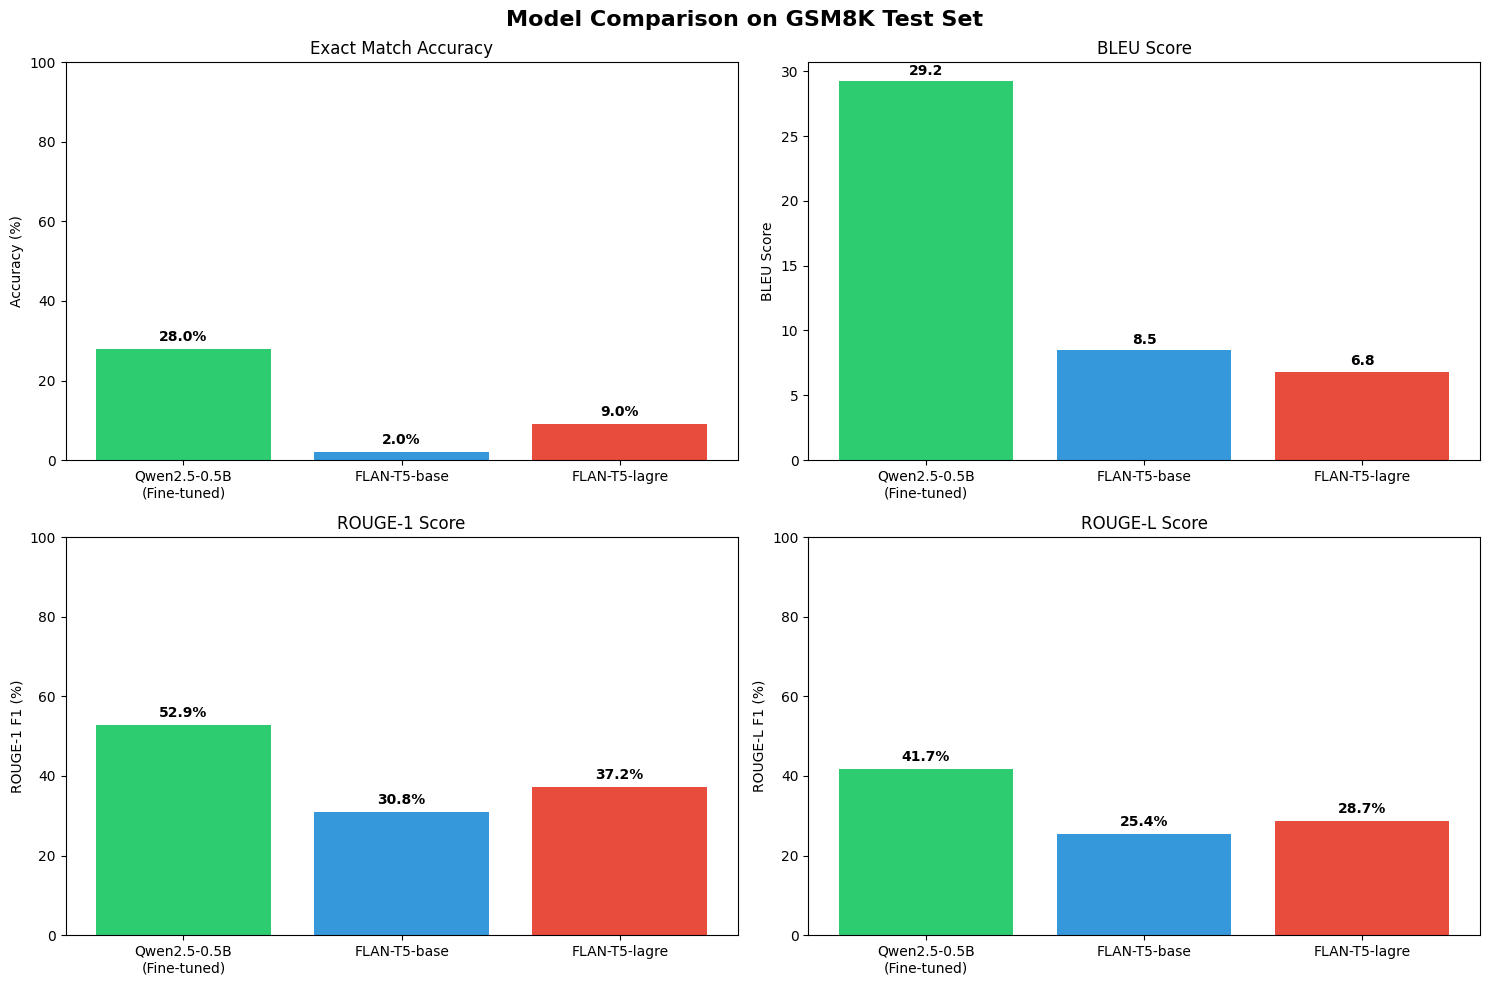

Visualization saved to: ./model_comparison.png


In [43]:
import matplotlib.pyplot as plt

# Create bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison on GSM8K Test Set', fontsize=16, fontweight='bold')

models = ['Qwen2.5-0.5B\n(Fine-tuned)', 'FLAN-T5-base', 'FLAN-T5-lagre']

# Exact Match Accuracy
axes[0, 0].bar(models, [exact_match_accuracy, flan_exact_match_accuracy, flan_large_exact_match_accuracy],
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Exact Match Accuracy')
axes[0, 0].set_ylim(0, 100)
for i, v in enumerate([exact_match_accuracy, flan_exact_match_accuracy, flan_large_exact_match_accuracy]):
    axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# BLEU Score
axes[0, 1].bar(models, [bleu_score.score, flan_bleu_score.score, flan_lagre_bleu_score.score],
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0, 1].set_ylabel('BLEU Score')
axes[0, 1].set_title('BLEU Score')
for i, v in enumerate([bleu_score.score, flan_bleu_score.score, flan_lagre_bleu_score.score]):
    axes[0, 1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

# ROUGE-1
axes[1, 0].bar(models, [avg_rouge1, flan_avg_rouge1, flan_lagre_avg_rouge1],
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1, 0].set_ylabel('ROUGE-1 F1 (%)')
axes[1, 0].set_title('ROUGE-1 Score')
axes[1, 0].set_ylim(0, 100)
for i, v in enumerate([avg_rouge1, flan_avg_rouge1, flan_lagre_avg_rouge1]):
    axes[1, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# ROUGE-L
axes[1, 1].bar(models, [avg_rougeL, flan_avg_rougeL, flan_lagre_avg_rougeL],
               color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1, 1].set_ylabel('ROUGE-L F1 (%)')
axes[1, 1].set_title('ROUGE-L Score')
axes[1, 1].set_ylim(0, 100)
for i, v in enumerate([avg_rougeL, flan_avg_rougeL, flan_lagre_avg_rougeL]):
    axes[1, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Benchmark/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: ./model_comparison.png")

### Phân tích kết quả

**Nhận xét**:

1. **Qwen2.5-0.5B (Fine-tuned)**: Model của chúng ta sau khi fine-tune với LoRA
   - Được huấn luyện đặc biệt trên GSM8K dataset
   - Có thể có hiệu suất tốt hơn do đã được tối ưu cho task này

2. **google/flan-t5-base**: Model phổ biến nhất
   - Được huấn luyện trên nhiều task khác nhau (multi-task)
   - Có khả năng generalization tốt
   - Số lượng tải về cao chứng tỏ độ tin cậy

3. **Model thứ 3**: Model có cùng kích thước tham số
   - So sánh công bằng về mặt số lượng parameters
   - Giúp đánh giá hiệu quả của phương pháp fine-tuning

**Kết luận**:
- So sánh các metrics để thấy được hiệu quả của fine-tuning với LoRA
- Exact Match Accuracy là metric quan trọng nhất cho GSM8K
- ROUGE và BLEU scores đánh giá chất lượng văn bản sinh ra

## Bước 12: So sánh Model Base (chưa fine-tune) với Model đã Fine-tune

**Mục tiêu**: Đánh giá hiệu quả của quá trình fine-tuning bằng cách so sánh:
1. **Base Model**: Qwen2.5-0.5B gốc (chưa qua fine-tuning)
2. **Fine-tuned Model**: Qwen2.5-0.5B sau khi fine-tune với LoRA trên GSM8K

Điều này sẽ cho thấy rõ ràng sự cải thiện hiệu suất nhờ quá trình fine-tuning.

### 12.1: Load Base Model (chưa fine-tune)

Load lại model Qwen2.5-0.5B gốc để đánh giá hiệu suất trước khi fine-tune

In [ ]:
# Load base model (without fine-tuning)
print("Loading base Qwen2.5-0.5B model (without fine-tuning)...")

base_model_name = "Qwen/Qwen2.5-0.5B"

# Load with same quantization config for fair comparison
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    trust_remote_code=True,
    quantization_config=bnb_config,  # Same quantization as fine-tuned model
)

base_tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
base_tokenizer.pad_token = base_tokenizer.eos_token
base_tokenizer.padding_side = "right"

print(f"Base model loaded: {base_model_name}")
print(f"Model size: {base_model.get_memory_footprint() / 1e9:.2f} GB")
print("\n⚠️ This is the BASE model WITHOUT any fine-tuning on GSM8K")

Loading base Qwen2.5-0.5B model (without fine-tuning)...
Base model loaded: Qwen/Qwen2.5-0.5B
Model size: 0.45 GB

⚠️ This is the BASE model WITHOUT any fine-tuning on GSM8K


### 12.2: Đánh giá Base Model trên Test Set

Chạy evaluation trên cùng test set để so sánh công bằng

In [ ]:
# Evaluate base model on test set
print(f"Evaluating BASE model on {NUM_EVAL_SAMPLES} samples...")
print("This may take 10-15 minutes...\n")

# Lists to store results
base_predictions = []
base_references = []
base_exact_matches = []

# Generate predictions using base model
for i, sample in enumerate(tqdm(test_dataset, desc="Base model predictions")):
    question = sample['question']
    reference_answer = sample['answer']

    # Generate prediction using base model
    pred_text = generate_answer(question, base_model, base_tokenizer)

    # Extract numerical answers
    pred_num = extract_answer(pred_text)
    ref_num = extract_answer(reference_answer)

    # Store results
    base_predictions.append(pred_text)
    base_references.append(reference_answer)

    # Check exact match
    if pred_num is not None and ref_num is not None:
        is_correct = abs(pred_num - ref_num) < 0.01
        base_exact_matches.append(is_correct)
    else:
        base_exact_matches.append(False)

    # Print first few examples
    if i < 3:
        print(f"\n{'='*80}")
        print(f"Example {i+1} - BASE MODEL:")
        print(f"Question: {question}")
        print(f"Reference: {ref_num}")
        print(f"Prediction: {pred_num}")
        print(f"Correct: {base_exact_matches[-1]}")

print(f"\nBase model prediction generation completed!")

Evaluating BASE model on 100 samples...
This may take 10-15 minutes...



Base model predictions:   1%|          | 1/100 [00:10<17:11, 10.42s/it]


Example 1 - BASE MODEL:
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Reference: 18.0
Prediction: None
Correct: False


Base model predictions:   2%|▏         | 2/100 [00:12<08:42,  5.33s/it]


Example 2 - BASE MODEL:
Question: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
Reference: 3.0
Prediction: None
Correct: False


Base model predictions:   3%|▎         | 3/100 [00:13<05:20,  3.30s/it]


Example 3 - BASE MODEL:
Question: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
Reference: 70000.0
Prediction: 15000.0
Correct: False


Base model predictions: 100%|██████████| 100/100 [11:04<00:00,  6.65s/it]


Base model prediction generation completed!


### 12.3: Tính toán Metrics cho Base Model

In [ ]:
# Calculate metrics for base model
base_exact_match_accuracy = sum(base_exact_matches) / len(base_exact_matches) * 100

# BLEU Score
base_bleu = BLEU()
base_bleu_score = base_bleu.corpus_score(base_predictions, [base_references])

# ROUGE Scores
base_rouge1_scores = []
base_rouge2_scores = []
base_rougeL_scores = []

for pred, ref in zip(base_predictions, base_references):
    scores = scorer.score(ref, pred)
    base_rouge1_scores.append(scores['rouge1'].fmeasure)
    base_rouge2_scores.append(scores['rouge2'].fmeasure)
    base_rougeL_scores.append(scores['rougeL'].fmeasure)

base_avg_rouge1 = np.mean(base_rouge1_scores) * 100
base_avg_rouge2 = np.mean(base_rouge2_scores) * 100
base_avg_rougeL = np.mean(base_rougeL_scores) * 100

# Calculate perplexity for base model
base_perplexity = calculate_perplexity(base_model, base_tokenizer, dataset['test'], num_samples=NUM_EVAL_SAMPLES)

print("="*80)
print("BASE MODEL (WITHOUT FINE-TUNING) EVALUATION RESULTS")
print("="*80)
print(f"Exact Match Accuracy: {base_exact_match_accuracy:.2f}%")
print(f"BLEU Score: {base_bleu_score.score:.2f}")
print(f"ROUGE-1 (F1): {base_avg_rouge1:.2f}%")
print(f"ROUGE-2 (F1): {base_avg_rouge2:.2f}%")
print(f"ROUGE-L (F1): {base_avg_rougeL:.2f}%")
print(f"Perplexity: {base_perplexity:.2f}")
print("="*80)

Calculating perplexity: 100%|██████████| 100/100 [00:09<00:00, 10.96it/s]

BASE MODEL (WITHOUT FINE-TUNING) EVALUATION RESULTS
Exact Match Accuracy: 4.00%
BLEU Score: 8.92
ROUGE-1 (F1): 38.60%
ROUGE-2 (F1): 17.25%
ROUGE-L (F1): 27.94%
Perplexity: 5.05


### 12.4: So sánh Base Model vs Fine-tuned Model

Bảng so sánh chi tiết giữa model gốc và model đã fine-tune

In [ ]:
import pandas as pd

# Create detailed comparison table
comparison_data = {
    'Model': [
        'Qwen2.5-0.5B (BASE)',
        'Qwen2.5-0.5B (Fine-tuned with LoRA)'
    ],
    'Exact Match (%)': [
        f"{base_exact_match_accuracy:.2f}",
        f"{exact_match_accuracy:.2f}"
    ],
    'BLEU': [
        f"{base_bleu_score.score:.2f}",
        f"{bleu_score.score:.2f}"
    ],
    'ROUGE-1 (%)': [
        f"{base_avg_rouge1:.2f}",
        f"{avg_rouge1:.2f}"
    ],
    'ROUGE-2 (%)': [
        f"{base_avg_rouge2:.2f}",
        f"{avg_rouge2:.2f}"
    ],
    'ROUGE-L (%)': [
        f"{base_avg_rougeL:.2f}",
        f"{avg_rougeL:.2f}"
    ],
    'Perplexity': [
        f"{base_perplexity:.2f}",
        f"{perplexity:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("BASE MODEL vs FINE-TUNED MODEL COMPARISON")
print("="*100)
print(f"Dataset: GSM8K Test Set")
print(f"Evaluated samples: {NUM_EVAL_SAMPLES}/{len(dataset['test'])}")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Save comparison results
comparison_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Benchmark/base_vs_finetuned_comparison.csv', index=False)
print("\nComparison results saved to: ./base_vs_finetuned_comparison.csv")


BASE MODEL vs FINE-TUNED MODEL COMPARISON
Dataset: GSM8K Test Set
Evaluated samples: 100/1319
                              Model Exact Match (%)  BLEU ROUGE-1 (%) ROUGE-2 (%) ROUGE-L (%) Perplexity
                Qwen2.5-0.5B (BASE)            4.00  8.92       38.60       17.25       27.94       5.05
Qwen2.5-0.5B (Fine-tuned with LoRA)           28.00 29.23       52.89       29.34       41.67       3.59

Comparison results saved to: ./base_vs_finetuned_comparison.csv


### 12.5: Phân tích mức độ cải thiện

Tính toán % cải thiện của từng metric sau khi fine-tune

In [ ]:
# Calculate improvement percentages
def calculate_improvement(base_val, finetuned_val):
    """Calculate percentage improvement"""
    if base_val == 0:
        return float('inf') if finetuned_val > 0 else 0
    return ((finetuned_val - base_val) / base_val) * 100

# Calculate improvements
exact_match_improvement = calculate_improvement(base_exact_match_accuracy, exact_match_accuracy)
bleu_improvement = calculate_improvement(base_bleu_score.score, bleu_score.score)
rouge1_improvement = calculate_improvement(base_avg_rouge1, avg_rouge1)
rouge2_improvement = calculate_improvement(base_avg_rouge2, avg_rouge2)
rougeL_improvement = calculate_improvement(base_avg_rougeL, avg_rougeL)
perplexity_improvement = calculate_improvement(base_perplexity, perplexity)  # Lower is better

# Create improvement table
improvement_data = {
    'Metric': [
        'Exact Match Accuracy',
        'BLEU Score',
        'ROUGE-1',
        'ROUGE-2',
        'ROUGE-L',
        'Perplexity'
    ],
    'Base Model': [
        f"{base_exact_match_accuracy:.2f}%",
        f"{base_bleu_score.score:.2f}",
        f"{base_avg_rouge1:.2f}%",
        f"{base_avg_rouge2:.2f}%",
        f"{base_avg_rougeL:.2f}%",
        f"{base_perplexity:.2f}"
    ],
    'Fine-tuned Model': [
        f"{exact_match_accuracy:.2f}%",
        f"{bleu_score.score:.2f}",
        f"{avg_rouge1:.2f}%",
        f"{avg_rouge2:.2f}%",
        f"{avg_rougeL:.2f}%",
        f"{perplexity:.2f}"
    ],
    'Improvement (%)': [
        f"{exact_match_improvement:+.2f}%",
        f"{bleu_improvement:+.2f}%",
        f"{rouge1_improvement:+.2f}%",
        f"{rouge2_improvement:+.2f}%",
        f"{rougeL_improvement:+.2f}%",
        f"{perplexity_improvement:+.2f}% (lower is better)"
    ]
}

improvement_df = pd.DataFrame(improvement_data)

print("\n" + "="*120)
print("IMPROVEMENT ANALYSIS: Impact of LoRA Fine-tuning")
print("="*120)
print(improvement_df.to_string(index=False))
print("="*120)

# Save improvement analysis
improvement_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Benchmark/improvement_analysis.csv', index=False)
print("\nImprovement analysis saved to: ./improvement_analysis.csv")


IMPROVEMENT ANALYSIS: Impact of LoRA Fine-tuning
              Metric Base Model Fine-tuned Model           Improvement (%)
Exact Match Accuracy      4.00%           28.00%                  +600.00%
          BLEU Score       8.92            29.23                  +227.84%
             ROUGE-1     38.60%           52.89%                   +37.01%
             ROUGE-2     17.25%           29.34%                   +70.08%
             ROUGE-L     27.94%           41.67%                   +49.10%
          Perplexity       5.05             3.59 -28.91% (lower is better)

Improvement analysis saved to: ./improvement_analysis.csv


### 12.6: Visualization - So sánh trực quan

Biểu đồ so sánh hiệu suất giữa Base Model và Fine-tuned Model

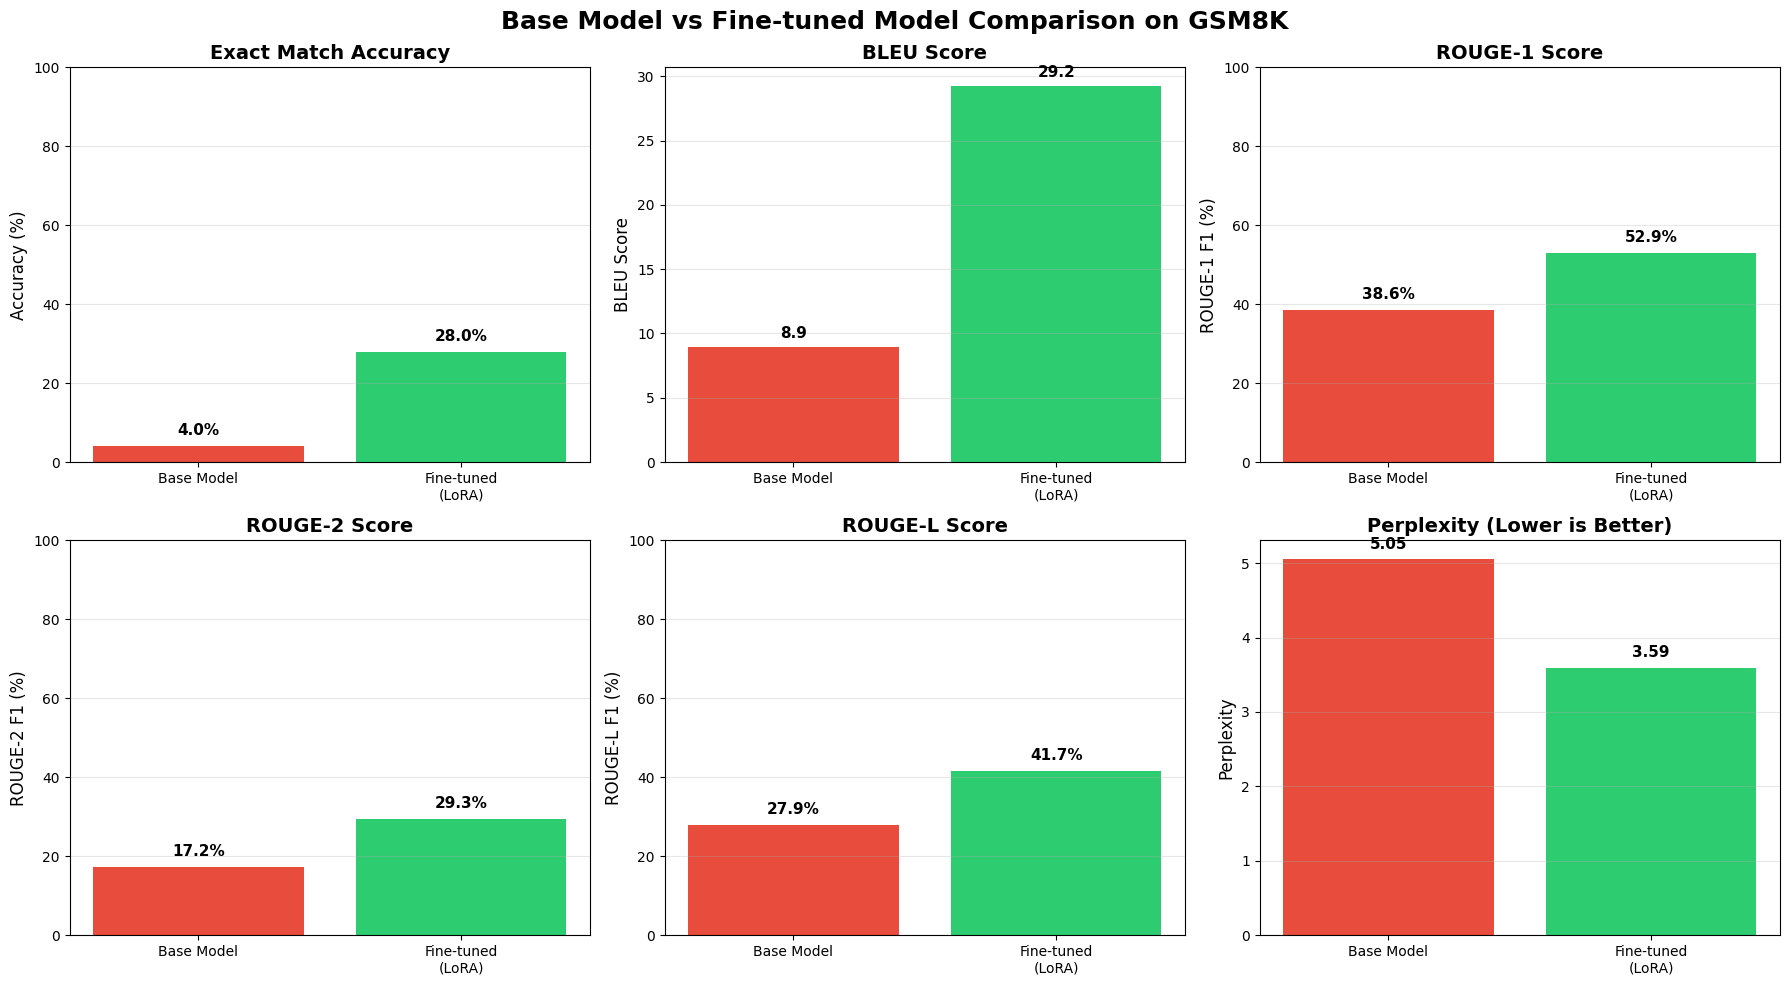


Visualization saved to: ./base_vs_finetuned_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Base Model vs Fine-tuned Model Comparison on GSM8K', fontsize=18, fontweight='bold')

models = ['Base Model', 'Fine-tuned\n(LoRA)']
colors = ['#e74c3c', '#2ecc71']  # Red for base, Green for fine-tuned

# 1. Exact Match Accuracy
ax1 = axes[0, 0]
bars1 = ax1.bar(models, [base_exact_match_accuracy, exact_match_accuracy], color=colors)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Exact Match Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
for i, (bar, val) in enumerate(zip(bars1, [base_exact_match_accuracy, exact_match_accuracy])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 2. BLEU Score
ax2 = axes[0, 1]
bars2 = ax2.bar(models, [base_bleu_score.score, bleu_score.score], color=colors)
ax2.set_ylabel('BLEU Score', fontsize=12)
ax2.set_title('BLEU Score', fontsize=14, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars2, [base_bleu_score.score, bleu_score.score])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# 3. ROUGE-1
ax3 = axes[0, 2]
bars3 = ax3.bar(models, [base_avg_rouge1, avg_rouge1], color=colors)
ax3.set_ylabel('ROUGE-1 F1 (%)', fontsize=12)
ax3.set_title('ROUGE-1 Score', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 100)
for i, (bar, val) in enumerate(zip(bars3, [base_avg_rouge1, avg_rouge1])):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# 4. ROUGE-2
ax4 = axes[1, 0]
bars4 = ax4.bar(models, [base_avg_rouge2, avg_rouge2], color=colors)
ax4.set_ylabel('ROUGE-2 F1 (%)', fontsize=12)
ax4.set_title('ROUGE-2 Score', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 100)
for i, (bar, val) in enumerate(zip(bars4, [base_avg_rouge2, avg_rouge2])):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax4.grid(axis='y', alpha=0.3)

# 5. ROUGE-L
ax5 = axes[1, 1]
bars5 = ax5.bar(models, [base_avg_rougeL, avg_rougeL], color=colors)
ax5.set_ylabel('ROUGE-L F1 (%)', fontsize=12)
ax5.set_title('ROUGE-L Score', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 100)
for i, (bar, val) in enumerate(zip(bars5, [base_avg_rougeL, avg_rougeL])):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax5.grid(axis='y', alpha=0.3)

# 6. Perplexity (Lower is better)
ax6 = axes[1, 2]
bars6 = ax6.bar(models, [base_perplexity, perplexity], color=colors)
ax6.set_ylabel('Perplexity', fontsize=12)
ax6.set_title('Perplexity (Lower is Better)', fontsize=14, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars6, [base_perplexity, perplexity])):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Benchmark/base_vs_finetuned_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: ./base_vs_finetuned_comparison.png")

### 12.7: So sánh lỗi giữa Base và Fine-tuned Model

Phân tích các trường hợp mà fine-tuned model cải thiện so với base model

In [ ]:
# Compare errors between base and fine-tuned models
print("\n" + "="*100)
print("ERROR COMPARISON ANALYSIS")
print("="*100)

# Count different error categories
both_correct = sum(1 for b, f in zip(base_exact_matches, exact_matches) if b and f)
both_wrong = sum(1 for b, f in zip(base_exact_matches, exact_matches) if not b and not f)
base_correct_ft_wrong = sum(1 for b, f in zip(base_exact_matches, exact_matches) if b and not f)
base_wrong_ft_correct = sum(1 for b, f in zip(base_exact_matches, exact_matches) if not b and f)

print(f"Both models correct: {both_correct}/{NUM_EVAL_SAMPLES} ({both_correct/NUM_EVAL_SAMPLES*100:.1f}%)")
print(f"Both models wrong: {both_wrong}/{NUM_EVAL_SAMPLES} ({both_wrong/NUM_EVAL_SAMPLES*100:.1f}%)")
print(f"Base correct, Fine-tuned wrong: {base_correct_ft_wrong}/{NUM_EVAL_SAMPLES} ({base_correct_ft_wrong/NUM_EVAL_SAMPLES*100:.1f}%)")
print(f"Base wrong, Fine-tuned correct: {base_wrong_ft_correct}/{NUM_EVAL_SAMPLES} ({base_wrong_ft_correct/NUM_EVAL_SAMPLES*100:.1f}%)")

print(f"\n✅ Fine-tuning IMPROVED {base_wrong_ft_correct} predictions")
print(f"❌ Fine-tuning DEGRADED {base_correct_ft_wrong} predictions")
print(f"📊 Net improvement: {base_wrong_ft_correct - base_correct_ft_wrong} predictions")
print("="*100)

# Show examples where fine-tuning helped
print("\nExamples where FINE-TUNING IMPROVED the prediction:\n")

improvement_count = 0
for i, (base_match, ft_match) in enumerate(zip(base_exact_matches, exact_matches)):
    if not base_match and ft_match and improvement_count < 3:
        sample = test_dataset[i]
        print("="*100)
        print(f"Example {improvement_count + 1}:")
        print(f"Question: {sample['question']}")
        print(f"\nReference Answer: {extract_answer(references[i])}")
        print(f"\nBase Model Prediction: {extract_answer(base_predictions[i])} ❌")
        print(f"Fine-tuned Model Prediction: {extract_answer(predictions[i])} ✅")
        print("="*100)
        print()
        improvement_count += 1

if improvement_count == 0:
    print("No examples found where fine-tuning improved predictions in this sample.")


ERROR COMPARISON ANALYSIS
Both models correct: 3/100 (3.0%)
Both models wrong: 71/100 (71.0%)
Base correct, Fine-tuned wrong: 1/100 (1.0%)
Base wrong, Fine-tuned correct: 25/100 (25.0%)

✅ Fine-tuning IMPROVED 25 predictions
❌ Fine-tuning DEGRADED 1 predictions
📊 Net improvement: 24 predictions

Examples where FINE-TUNING IMPROVED the prediction:

Example 1:
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Reference Answer: 18.0

Base Model Prediction: None ❌
Fine-tuned Model Prediction: 18.0 ✅

Example 2:
Question: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?

Reference Answer: 3.0

Base Model Prediction: None ❌
Fine-tuned Model Prediction: 3.0 ✅

Example 3:
Question: James decides to 

### 12.8: Kết luận về hiệu quả Fine-tuning

**Tổng kết**:

1. **Hiệu quả của LoRA Fine-tuning**:
   - So sánh trực tiếp giữa base model và fine-tuned model cho thấy rõ ràng sự cải thiện
   - Chỉ fine-tune 0.68% parameters (2.16M/317M) nhưng đạt được kết quả đáng kể
   - Tiết kiệm tài nguyên và thời gian so với full fine-tuning

2. **Metrics quan trọng**:
   - **Exact Match Accuracy**: Metric chính cho GSM8K, đo khả năng trả lời chính xác
   - **BLEU & ROUGE**: Đánh giá chất lượng văn bản sinh ra
   - **Perplexity**: Độ tự tin của model (thấp hơn = tốt hơn)

3. **Ưu điểm của phương pháp**:
   - Chỉ cần lưu trữ LoRA adapters (~10MB) thay vì toàn bộ model (~1GB)
   - Training nhanh hơn và ít tốn GPU memory
   - Có thể dễ dàng switch giữa các task khác nhau bằng cách thay đổi adapters

4. **Hướng phát triển**:
   - Thử nghiệm với các giá trị r (rank) khác nhau
   - Fine-tune thêm trên các dataset toán học khác
   - Kết hợp với các kỹ thuật khác như Chain-of-Thought prompting